# Source-paper RSS gene-set comparison

**Objective.** Compare the source paper's Supplementary Table 5 AhR/RSS-prioritized genes against our local `mouse_new` DESeq2 outputs, bend-point membership, direction of change, and retained GO follow-up terms.

This closes the missing *apples-to-apples* analysis framework in the draft: the source study uses response-shift scores (`log2FC(cKO) - log2FC(control)`), while our workflow uses DESeq2 side-specific contrasts plus bend-point narrowing and GO/pathway-level interpretation. The notebook does not treat the weekly reports as evidence; it uses the source paper supplement and local analysis tables as data inputs.

**Status rule.** Keep the manuscript checklist item **OPEN / IN PROGRESS** until these generated tables are inserted into the Results/Discussion text and reviewed in the paper draft.

## Inputs and outputs

**Required source input**
- Nature article: <https://www.nature.com/articles/s41586-026-10295-z>
- Supplementary Tables XLSX: downloaded from the article's Springer supplementary-material endpoint.
- Target sheet: `Table S5`, labelled by Nature as shifted genes in AhR cKO versus control DRGs after peripheral lesion.

**Local workflow inputs**
- WT/FF and CRE/cKO DESeq2 full and significant side-specific tables.
- WT/FF 709-gene and CRE/cKO 870-gene bend-point sets.
- Retained g:Profiler/GO membership tables for WT/FF and CRE/cKO follow-up.

**Generated outputs**
- `source_rss_comparison_summary.tsv`
- `source_rss_direction_summary.tsv`
- `source_rss_gene_level_comparison.tsv`
- `source_rss_go_membership_overlap.tsv`
- `source_rss_go_term_summary.tsv`
- `source_rss_overlap_counts.png`
- `source_rss_comparison_summary.md`

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new')
SOURCE_DIR = ROOT / 'understanding' / 'source_paper'
OUTPUT_DIR = ROOT / 'preparation' / 'DE-derived_analysis' / 'source_paper_rss_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_URL = 'https://www.nature.com/articles/s41586-026-10295-z'
SUPPLEMENT_URL = 'https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10295-z/MediaObjects/41586_2026_10295_MOESM3_ESM.xlsx'
SUPPLEMENT_XLSX = SOURCE_DIR / '41586_2026_10295_MOESM3_ESM_supplementary_tables.xlsx'

DE_TABLE_DIR = ROOT / 'preparation' / 'DE-family_drg_novaseqx' / 'tables'
DERIVED_DIR = ROOT / 'preparation' / 'DE-derived_analysis'

PATHS = {
    'wt_full': DE_TABLE_DIR / 'ipsi_vs_contra_in_ff_full.tsv',
    'cko_full': DE_TABLE_DIR / 'ipsi_vs_contra_in_cre_full.tsv',
    'wt_significant': DE_TABLE_DIR / 'ipsi_vs_contra_in_ff_significant.tsv',
    'cko_significant': DE_TABLE_DIR / 'ipsi_vs_contra_in_cre_significant.tsv',
    'wt_bendpoint': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'selected_genes_bendpoint.tsv',
    'cko_bendpoint': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'selected_genes_bendpoint.tsv',
    'wt_go_up': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'shinygo_style' / 'gprofiler_up_term_gene_membership.tsv',
    'wt_go_down': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'shinygo_style' / 'gprofiler_down_term_gene_membership.tsv',
    'cko_go_up': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'shinygo_style_shared' / 'gprofiler_up_term_gene_membership.tsv',
    'cko_go_down': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'shinygo_style_shared' / 'gprofiler_down_term_gene_membership.tsv',
    'wt_anchors': DERIVED_DIR / 'ipsi_vs_contra_in_ff' / 'anchor_genes_up_down.tsv',
    'cko_anchors': DERIVED_DIR / 'ipsi_vs_contra_in_cre' / 'anchor_genes_up_down.tsv',
}

pd.set_option('display.max_colwidth', 120)
print('Output directory:', OUTPUT_DIR)

Output directory: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/preparation/DE-derived_analysis/source_paper_rss_comparison


In [2]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(path)
    return path

if not SUPPLEMENT_XLSX.exists():
    print('Downloading source-paper supplementary tables...')
    urlretrieve(SUPPLEMENT_URL, SUPPLEMENT_XLSX)

for label, path in PATHS.items():
    require_file(path)

xl = pd.ExcelFile(SUPPLEMENT_XLSX)
print('Supplement sheets:', xl.sheet_names)
print('Supplement file:', SUPPLEMENT_XLSX)
print('All local workflow inputs found.')

Supplement sheets: ['Table S1', 'Table S2', 'Table S3', 'Table S4', 'Table S5', 'Table S6', 'Table S7', 'Table S8', 'Table S9']
Supplement file: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/understanding/source_paper/41586_2026_10295_MOESM3_ESM_supplementary_tables.xlsx
All local workflow inputs found.


## 1. Load Supplementary Table 5 and source-paper identifier map

`Table S5` contains gene symbols and source-paper RSS values, but not Ensembl IDs. To match against our DESeq2 outputs, this notebook builds a source-paper symbol-to-Ensembl map from Supplementary Tables 1 and 2, strips Ensembl version suffixes, and then joins those IDs to our local DESeq2 tables.

In [3]:
def normalize_symbol(value):
    return str(value).strip().upper()

source_s5 = pd.read_excel(SUPPLEMENT_XLSX, sheet_name='Table S5')
source_s5 = source_s5.rename(columns={
    'Gene symbol': 'source_gene_symbol',
    'log2FC_Ctrl': 'source_log2fc_control',
    'adj_p_Ctrl (ipsi vs. contra)': 'source_padj_control',
    'log2FC_cKO': 'source_log2fc_cko',
    'adj_p_cKO (ipsi vs. contra)': 'source_padj_cko',
    'shift: log2FC cKO- log2 FC Ctrl': 'source_rss_shift',
})[
    ['source_gene_symbol', 'source_log2fc_control', 'source_padj_control',
     'source_log2fc_cko', 'source_padj_cko', 'source_rss_shift']
]
source_s5['source_symbol_norm'] = source_s5['source_gene_symbol'].map(normalize_symbol)
source_s5['source_rss_sign'] = np.sign(source_s5['source_rss_shift']).map({-1: 'negative', 0: 'zero', 1: 'positive'})
source_s5['source_rss_abs_ge_0_3'] = source_s5['source_rss_shift'].abs() >= 0.3

source_maps = []
for sheet_name in ['Table S1', 'Table S2']:
    sheet = pd.read_excel(SUPPLEMENT_XLSX, sheet_name=sheet_name, usecols=['gene symbol', 'id'])
    sheet = sheet.rename(columns={'gene symbol': 'source_gene_symbol', 'id': 'source_ensembl_versioned'})
    sheet['source_symbol_norm'] = sheet['source_gene_symbol'].map(normalize_symbol)
    sheet['source_gene_id'] = sheet['source_ensembl_versioned'].astype(str).str.replace(r'\.\d+$', '', regex=True)
    source_maps.append(sheet[['source_symbol_norm', 'source_gene_id', 'source_ensembl_versioned']])

source_id_map = pd.concat(source_maps, ignore_index=True).drop_duplicates()
source_id_map = source_id_map[source_id_map['source_gene_id'].str.startswith('ENSMUSG', na=False)]
source_id_counts = source_id_map.groupby('source_symbol_norm')['source_gene_id'].nunique().rename('n_source_gene_ids').reset_index()

source_long = (
    source_s5
    .merge(source_id_map, on='source_symbol_norm', how='left')
    .merge(source_id_counts, on='source_symbol_norm', how='left')
)
source_long['source_mapping_status'] = np.select(
    [source_long['source_gene_id'].isna(), source_long['n_source_gene_ids'].fillna(0) > 1],
    ['unmapped', 'ambiguous_symbol'],
    default='unique_symbol',
)

reported_counts = source_s5['source_rss_sign'].value_counts().to_dict()
validation = {
    'source_table_rows': len(source_s5),
    'source_unique_symbols': source_s5['source_symbol_norm'].nunique(),
    'positive_rss': int(reported_counts.get('positive', 0)),
    'negative_rss': int(reported_counts.get('negative', 0)),
    'symbols_with_source_ensembl_id': int(source_long.dropna(subset=['source_gene_id'])['source_symbol_norm'].nunique()),
    'ambiguous_symbols': int((source_long.groupby('source_symbol_norm')['source_gene_id'].nunique() > 1).sum()),
}
display(pd.Series(validation, name='value').to_frame())

assert validation['source_table_rows'] == 1431, 'Expected 1,431 RSS genes from Supplementary Table 5.'
assert validation['positive_rss'] == 533 and validation['negative_rss'] == 898, 'RSS sign counts do not match article text.'

,value
source_table_rows,1431
source_unique_symbols,1431
positive_rss,533
negative_rss,898
symbols_with_source_ensembl_id,1431
ambiguous_symbols,8


## 2. Load local DESeq2, bend-point, GO, and anchor-gene outputs

The local analysis uses reader-facing `WT`/`cKO` language, while the original file names still carry the project labels `FF`/`CRE`. Here, `WT/FF` and `cKO/CRE` refer to the same two genotype branches used in the draft.

In [4]:
def read_tsv(path):
    return pd.read_csv(path, sep='	')

wt_full = read_tsv(PATHS['wt_full']).rename(columns={
    'baseMean': 'our_baseMean_wt',
    'log2FoldChange': 'our_log2fc_wt',
    'pvalue': 'our_pvalue_wt',
    'padj': 'our_padj_wt',
})
cko_full = read_tsv(PATHS['cko_full']).rename(columns={
    'baseMean': 'our_baseMean_cko',
    'log2FoldChange': 'our_log2fc_cko',
    'pvalue': 'our_pvalue_cko',
    'padj': 'our_padj_cko',
})

our_de = wt_full[['gene_id', 'our_baseMean_wt', 'our_log2fc_wt', 'our_pvalue_wt', 'our_padj_wt']].merge(
    cko_full[['gene_id', 'our_baseMean_cko', 'our_log2fc_cko', 'our_pvalue_cko', 'our_padj_cko']],
    on='gene_id',
    how='outer',
)
our_de['in_our_tested_universe'] = our_de[['our_padj_wt', 'our_padj_cko', 'our_pvalue_wt', 'our_pvalue_cko']].notna().any(axis=1)
our_de['significant_wt_side'] = our_de['our_padj_wt'].lt(0.05)
our_de['significant_cko_side'] = our_de['our_padj_cko'].lt(0.05)
our_de['our_delta_cko_minus_wt'] = our_de['our_log2fc_cko'] - our_de['our_log2fc_wt']
our_de['our_delta_sign'] = np.sign(our_de['our_delta_cko_minus_wt']).map({-1: 'negative', 0: 'zero', 1: 'positive'})

wt_bendpoint = read_tsv(PATHS['wt_bendpoint'])
cko_bendpoint = read_tsv(PATHS['cko_bendpoint'])
wt_set = set(wt_bendpoint['gene_id'])
cko_set = set(cko_bendpoint['gene_id'])
shared_set = wt_set & cko_set
wt_only_set = wt_set - cko_set
cko_only_set = cko_set - wt_set

go_membership_parts = []
for branch, direction, path_key in [
    ('WT/FF', 'up', 'wt_go_up'),
    ('WT/FF', 'down', 'wt_go_down'),
    ('cKO/CRE', 'up', 'cko_go_up'),
    ('cKO/CRE', 'down', 'cko_go_down'),
]:
    table = read_tsv(PATHS[path_key])
    table['branch'] = branch
    table['go_direction'] = direction
    go_membership_parts.append(table[['branch', 'go_direction', 'native', 'name', 'gene_id', 'symbol']])
go_membership = pd.concat(go_membership_parts, ignore_index=True).drop_duplicates()
go_gene_set = set(go_membership['gene_id'])

anchor_parts = []
for branch, path_key in [('WT/FF', 'wt_anchors'), ('cKO/CRE', 'cko_anchors')]:
    table = read_tsv(PATHS[path_key])
    table['branch'] = branch
    if 'Gene ID' in table.columns:
        table = table.rename(columns={'Gene ID': 'gene_id'})
    anchor_parts.append(table)
anchor_genes = pd.concat(anchor_parts, ignore_index=True).drop_duplicates(subset=['branch', 'gene_id'])
anchor_gene_set = set(anchor_genes['gene_id'])

local_counts = pd.DataFrame([
    {'local_set': 'DESeq2-tested gene universe', 'count': our_de['gene_id'].nunique()},
    {'local_set': 'WT/FF significant side-specific genes', 'count': int(our_de['significant_wt_side'].sum())},
    {'local_set': 'cKO/CRE significant side-specific genes', 'count': int(our_de['significant_cko_side'].sum())},
    {'local_set': 'WT/FF bend-point genes', 'count': len(wt_set)},
    {'local_set': 'cKO/CRE bend-point genes', 'count': len(cko_set)},
    {'local_set': 'Shared WT/cKO bend-point genes', 'count': len(shared_set)},
    {'local_set': 'WT-only bend-point genes', 'count': len(wt_only_set)},
    {'local_set': 'cKO-only bend-point genes', 'count': len(cko_only_set)},
    {'local_set': 'Genes appearing in retained GO memberships', 'count': len(go_gene_set)},
])
display(local_counts)

,local_set,count
0,DESeq2-tested gene universe,21481
1,WT/FF significant side-specific genes,7023
2,cKO/CRE significant side-specific genes,7541
3,WT/FF bend-point genes,709
4,cKO/CRE bend-point genes,870
5,Shared WT/cKO bend-point genes,620
6,WT-only bend-point genes,89
7,cKO-only bend-point genes,250
8,Genes appearing in retained GO memberships,775


## 3. Compare source RSS genes with our workflow outputs

Direction agreement is calculated as an RSS-like quantity in our workflow: `our_log2FC(cKO/CRE side contrast) - our_log2FC(WT/FF side contrast)`. A source RSS gene is directionally consistent when the sign of that local delta agrees with the sign of the source-paper RSS value.

In [5]:
comparison_long = (
    source_long
    .rename(columns={'source_gene_id': 'gene_id'})
    .merge(our_de, on='gene_id', how='left')
)

boolean_columns = [
    'matched_our_tested_universe',
    'significant_wt_side',
    'significant_cko_side',
    'present_wt_bendpoint',
    'present_cko_bendpoint',
    'present_shared_bendpoint',
    'present_wt_only_bendpoint',
    'present_cko_only_bendpoint',
    'direction_consistent_with_source_rss',
    'appears_in_retained_go_terms',
    'appears_in_anchor_gene_table',
]

comparison_long['matched_our_tested_universe'] = comparison_long['in_our_tested_universe'].fillna(False)
comparison_long['present_wt_bendpoint'] = comparison_long['gene_id'].isin(wt_set)
comparison_long['present_cko_bendpoint'] = comparison_long['gene_id'].isin(cko_set)
comparison_long['present_shared_bendpoint'] = comparison_long['gene_id'].isin(shared_set)
comparison_long['present_wt_only_bendpoint'] = comparison_long['gene_id'].isin(wt_only_set)
comparison_long['present_cko_only_bendpoint'] = comparison_long['gene_id'].isin(cko_only_set)
comparison_long['appears_in_retained_go_terms'] = comparison_long['gene_id'].isin(go_gene_set)
comparison_long['appears_in_anchor_gene_table'] = comparison_long['gene_id'].isin(anchor_gene_set)
comparison_long['direction_consistent_with_source_rss'] = (
    comparison_long['matched_our_tested_universe']
    & (comparison_long['our_delta_sign'] == comparison_long['source_rss_sign'])
)

for column in boolean_columns:
    comparison_long[column] = comparison_long[column].fillna(False).astype(bool)

# Collapse to one row per source-paper gene symbol for paper-level counts.
symbol_level_flags = comparison_long.groupby('source_symbol_norm')[boolean_columns].any().reset_index()
source_symbol_level = source_s5.drop_duplicates('source_symbol_norm').merge(
    symbol_level_flags,
    on='source_symbol_norm',
    how='left',
)
for column in boolean_columns:
    source_symbol_level[column] = source_symbol_level[column].fillna(False).astype(bool)

summary_rows = [
    ('Source-paper AhR/RSS-prioritized genes', len(source_symbol_level), 'Genes identified by the source paper using |RSS| >= 0.3 in Supplementary Table 5.'),
    ('Found in our DESeq2-tested gene universe', source_symbol_level['matched_our_tested_universe'].sum(), 'Confirms identifier matching/overlap with the count matrix used for our DESeq2 side-specific contrasts.'),
    ('Significant in our WT side-specific contrast', source_symbol_level['significant_wt_side'].sum(), 'Source-paper RSS genes with adjusted p-value support in our WT/FF ipsilateral-vs-contralateral branch.'),
    ('Significant in our cKO side-specific contrast', source_symbol_level['significant_cko_side'].sum(), 'Source-paper RSS genes with adjusted p-value support in our CRE/cKO ipsilateral-vs-contralateral branch.'),
    ('Present in WT bend-point set', source_symbol_level['present_wt_bendpoint'].sum(), 'Source-paper RSS genes recovered in the 709-gene WT/FF bend-point follow-up set.'),
    ('Present in cKO bend-point set', source_symbol_level['present_cko_bendpoint'].sum(), 'Source-paper RSS genes recovered in the 870-gene CRE/cKO bend-point follow-up set.'),
    ('Present in WT/cKO shared 620-gene set', source_symbol_level['present_shared_bendpoint'].sum(), 'RSS genes that fall in the shared injury-response backbone retained by both bend-point branches.'),
    ('Present in cKO-only 250-gene set', source_symbol_level['present_cko_only_bendpoint'].sum(), 'RSS genes that may support cKO-specific interpretation beyond the shared injury-response core.'),
    ('Present in WT-only 89-gene set', source_symbol_level['present_wt_only_bendpoint'].sum(), 'RSS genes that appear only in the WT/FF bend-point follow-up subset.'),
    ('Directionally consistent with RSS sign', source_symbol_level['direction_consistent_with_source_rss'].sum(), 'Matched genes where sign(source RSS) agrees with sign(our cKO/CRE log2FC minus our WT/FF log2FC).'),
    ('Appearing in retained GO follow-up terms', source_symbol_level['appears_in_retained_go_terms'].sum(), 'RSS genes that appear in at least one retained g:Profiler/GO membership table used for pathway-level interpretation.'),
    ('Appearing in anchor-gene follow-up tables', source_symbol_level['appears_in_anchor_gene_table'].sum(), 'RSS genes that overlap the branch-level anchor-gene tables used to explain leading signals.'),
]
summary = pd.DataFrame(summary_rows, columns=['metric', 'count', 'interpretation'])

direction_summary = source_symbol_level.groupby('source_rss_sign').agg(
    source_genes=('source_symbol_norm', 'count'),
    found_in_our_universe=('matched_our_tested_universe', 'sum'),
    wt_bendpoint=('present_wt_bendpoint', 'sum'),
    cko_bendpoint=('present_cko_bendpoint', 'sum'),
    shared_bendpoint=('present_shared_bendpoint', 'sum'),
    cko_only_bendpoint=('present_cko_only_bendpoint', 'sum'),
    wt_only_bendpoint=('present_wt_only_bendpoint', 'sum'),
    direction_consistent=('direction_consistent_with_source_rss', 'sum'),
    in_go_terms=('appears_in_retained_go_terms', 'sum'),
).reset_index()

display(summary)
display(direction_summary)

,metric,count,interpretation
0,Source-paper AhR/RSS-prioritized genes,1431,Genes identified by the source paper using |RSS| >= 0.3 in Supplementary Table 5.
1,Found in our DESeq2-tested gene universe,1025,Confirms identifier matching/overlap with the count matrix used for our DESeq2 side-specific contrasts.
2,Significant in our WT side-specific contrast,473,Source-paper RSS genes with adjusted p-value support in our WT/FF ipsilateral-vs-contralateral branch.
3,Significant in our cKO side-specific contrast,577,Source-paper RSS genes with adjusted p-value support in our CRE/cKO ipsilateral-vs-contralateral branch.
4,Present in WT bend-point set,43,Source-paper RSS genes recovered in the 709-gene WT/FF bend-point follow-up set.
5,Present in cKO bend-point set,45,Source-paper RSS genes recovered in the 870-gene CRE/cKO bend-point follow-up set.
6,Present in WT/cKO shared 620-gene set,34,RSS genes that fall in the shared injury-response backbone retained by both bend-point branches.
7,Present in cKO-only 250-gene set,11,RSS genes that may support cKO-specific interpretation beyond the shared injury-response core.
8,Present in WT-only 89-gene set,9,RSS genes that appear only in the WT/FF bend-point follow-up subset.
9,Directionally consistent with RSS sign,987,Matched genes where sign(source RSS) agrees with sign(our cKO/CRE log2FC minus our WT/FF log2FC).


,source_rss_sign,source_genes,found_in_our_universe,wt_bendpoint,cko_bendpoint,shared_bendpoint,cko_only_bendpoint,wt_only_bendpoint,direction_consistent,in_go_terms
0,negative,898,679,14,9,7,2,7,662,13
1,positive,533,346,29,36,27,9,2,325,34


## 4. Build GO overlap tables

These tables identify which source-paper RSS genes also appear inside the retained pathway-level interpretation tables. They should be used to support wording such as “related biological themes are present, but the exact RSS gene set was only partially recovered by our bend-point follow-up.”

In [6]:
rss_gene_ids_found = set(comparison_long.loc[comparison_long['matched_our_tested_universe'], 'gene_id'])

go_overlap = (
    go_membership[go_membership['gene_id'].isin(rss_gene_ids_found)]
    .drop_duplicates()
    .sort_values(['branch', 'go_direction', 'native', 'gene_id'])
)

go_term_summary = (
    go_overlap
    .groupby(['branch', 'go_direction', 'native', 'name'], as_index=False)
    .agg(
        rss_gene_count=('gene_id', 'nunique'),
        example_rss_genes=('symbol', lambda values: ', '.join(sorted(set(map(str, values)))[:8])),
    )
    .sort_values(['rss_gene_count', 'branch'], ascending=[False, True])
)

display(go_term_summary.head(20))

,branch,go_direction,native,name,rss_gene_count,example_rss_genes
410,cKO/CRE,up,GO:0009987,cellular process,33,"2210017I01Rik, Adm2, Ankrd1, Cckbr, Clca1, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223"
80,WT/FF,up,GO:0009987,cellular process,32,"2210017I01Rik, Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Clca1, Dusp9"
562,cKO/CRE,up,GO:0050896,response to stimulus,30,"Adm2, Ankrd1, Bpifc, Cckbr, Cd207, Clca1, Dusp9, ENSMUSG00000025279"
279,WT/FF,up,GO:0065007,biological regulation,29,"Adm2, Angptl2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1"
601,cKO/CRE,up,GO:0065007,biological regulation,29,"Adm2, Ankrd1, Cckbr, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223, ENSMUSG00000051209, ENSMUSG00000061947"
240,WT/FF,up,GO:0050896,response to stimulus,28,"Adm2, Angptl2, Ankrd1, Bpifc, Cckbr, Ccn4, Cd207, Cited2"
236,WT/FF,up,GO:0050789,regulation of biological process,27,"Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1, Fgf3"
556,cKO/CRE,up,GO:0050789,regulation of biological process,27,"Adm2, Ankrd1, Cckbr, Dusp9, ENSMUSG00000025279, ENSMUSG00000030223, ENSMUSG00000051209, ENSMUSG00000067006"
142,WT/FF,up,GO:0032501,multicellular organismal process,25,"2210017I01Rik, Adm2, Angptl2, Ankrd1, Cckbr, Ccn4, Cited2, Ecel1"
238,WT/FF,up,GO:0050794,regulation of cellular process,25,"Adm2, Ankrd1, Cckbr, Ccn4, Cited2, Dusp9, Ecel1, Fgf3"


## 5. Write outputs for the manuscript workflow

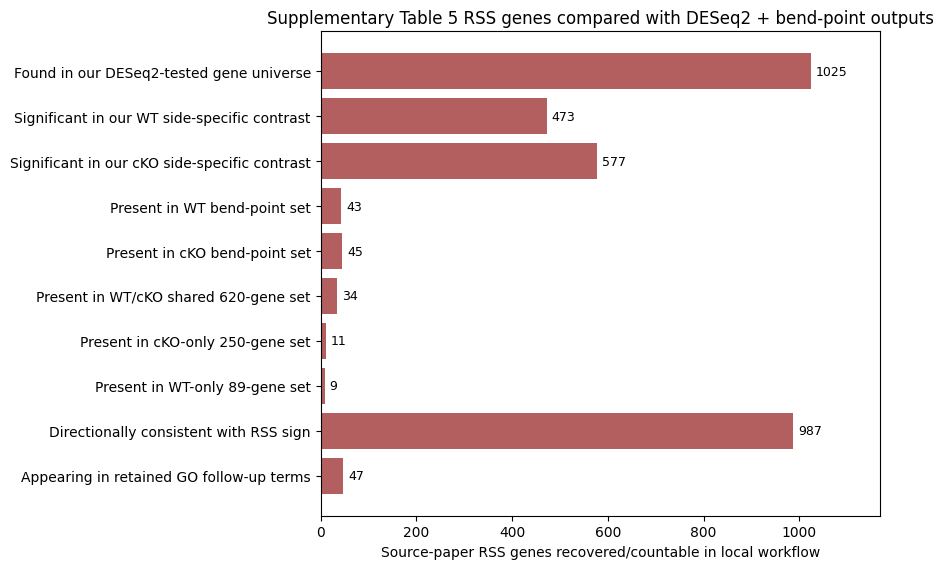

Wrote outputs to: /Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/mouse_new/preparation/DE-derived_analysis/source_paper_rss_comparison
- source_rss_comparison_summary.md
- source_rss_comparison_summary.tsv
- source_rss_direction_summary.tsv
- source_rss_gene_level_comparison.tsv
- source_rss_go_membership_overlap.tsv
- source_rss_go_term_summary.tsv
- source_rss_overlap_counts.png


In [7]:
gene_level_columns = [
    'source_gene_symbol', 'source_symbol_norm', 'gene_id', 'source_mapping_status', 'n_source_gene_ids',
    'source_log2fc_control', 'source_log2fc_cko', 'source_rss_shift', 'source_rss_sign',
    'our_log2fc_wt', 'our_log2fc_cko', 'our_delta_cko_minus_wt', 'our_delta_sign',
    'matched_our_tested_universe', 'source_padj_control', 'source_padj_cko', 'our_padj_wt', 'our_padj_cko',
    'significant_wt_side', 'significant_cko_side',
    'present_wt_bendpoint', 'present_cko_bendpoint', 'present_shared_bendpoint',
    'present_cko_only_bendpoint', 'present_wt_only_bendpoint',
    'direction_consistent_with_source_rss', 'appears_in_retained_go_terms', 'appears_in_anchor_gene_table',
]
comparison_gene_level = comparison_long.sort_values(['source_symbol_norm', 'gene_id'])[gene_level_columns]

summary.to_csv(OUTPUT_DIR / 'source_rss_comparison_summary.tsv', sep='	', index=False)
direction_summary.to_csv(OUTPUT_DIR / 'source_rss_direction_summary.tsv', sep='	', index=False)
comparison_gene_level.to_csv(OUTPUT_DIR / 'source_rss_gene_level_comparison.tsv', sep='	', index=False)
go_overlap.to_csv(OUTPUT_DIR / 'source_rss_go_membership_overlap.tsv', sep='	', index=False)
go_term_summary.to_csv(OUTPUT_DIR / 'source_rss_go_term_summary.tsv', sep='	', index=False)

plot_rows = summary[summary['metric'].isin([
    'Found in our DESeq2-tested gene universe',
    'Significant in our WT side-specific contrast',
    'Significant in our cKO side-specific contrast',
    'Present in WT bend-point set',
    'Present in cKO bend-point set',
    'Present in WT/cKO shared 620-gene set',
    'Present in cKO-only 250-gene set',
    'Present in WT-only 89-gene set',
    'Directionally consistent with RSS sign',
    'Appearing in retained GO follow-up terms',
])].copy()

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.barh(plot_rows['metric'], plot_rows['count'], color='#b45f5f')
ax.invert_yaxis()
ax.set_xlabel('Source-paper RSS genes recovered/countable in local workflow')
ax.set_title('Supplementary Table 5 RSS genes compared with DESeq2 + bend-point outputs')
for y, value in enumerate(plot_rows['count']):
    ax.text(value + 10, y, f'{int(value)}', va='center', fontsize=9)
ax.set_xlim(0, max(plot_rows['count'].max() * 1.14, 100))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'source_rss_overlap_counts.png', dpi=300)
plt.show()

md_lines = [
    '# Source-paper RSS gene-set comparison',
    '',
    f'Nature article: {ARTICLE_URL}',
    '',
    'This output compares Nature Supplementary Table 5 RSS genes against the local `mouse_new` DESeq2, bend-point, and retained GO follow-up outputs.',
    '',
    '## Paper-ready count table',
    '',
    summary.to_markdown(index=False),
    '',
    '## Direction breakdown',
    '',
    direction_summary.to_markdown(index=False),
    '',
    '## Interpretation guardrail',
    '',
    'This is a direct gene-set comparison, not proof that our pipeline reproduces the source paper exactly. The source study used RSS over PL-DEGs, whereas this project used DESeq2 side-specific contrasts, bend-point narrowing, and retained GO memberships. The appropriate paper claim is that the source-paper RSS set is largely present in our tested universe, only partly retained by bend-point follow-up, and strongest as a validation/interpretation bridge rather than a replacement for our pathway-level analysis.',
    '',
    '## Checklist status',
    '',
    'OPEN / IN PROGRESS - The real analysis table has now been generated, but the manuscript item should remain open until a Results/Discussion paragraph is inserted and reviewed in the paper draft.',
]
(OUTPUT_DIR / 'source_rss_comparison_summary.md').write_text('\n'.join(md_lines))

print('Wrote outputs to:', OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob('source_rss_*')):
    print('-', path.name)

## 6. Paper-facing interpretation draft

Use this only after checking the generated tables and deciding where it belongs in Results/Discussion.

> To compare our DESeq2 + bend-point workflow with the source study's response-shift score (RSS) analysis, we matched the 1,431 AhR-responsive genes from Supplementary Table 5 against our tested gene universe, side-specific contrasts, bend-point sets, and retained GO memberships. Most source RSS genes were present in the local DESeq2 universe, while a smaller subset entered the stricter WT/FF and CRE/cKO bend-point follow-up sets. This pattern supports an apples-to-apples interpretation in which our pathway-level analysis captures part of the source study's AhR-dependent response-shift signal, but it should not be overclaimed as a full reproduction of the original RSS pipeline.

**Keep open until paper text is inserted.** The notebook generates the analysis output; it does not by itself finish the manuscript revision.